<a href="https://colab.research.google.com/github/vision1011/Artificial-Intelligence-and-Machine-Learning/blob/main/LanguageTask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
# Import libraries and load the dataset
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import tensorflow as tf
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK components
nltk.download('stopwords')
nltk.download('wordnet')

# Path to teacher's dataset
file_path = "/content/drive/MyDrive/AI & Machine learning/Book_review.csv"
df = pd.read_csv(file_path)

# Standardize column names to fix the KeyError
df.columns = df.columns.str.strip()
# Mapping teacher's names to our logic
df = df[["rating", "reviewText", "summary"]].copy()

# Fill missing values and combine text columns
df["reviewText"] = df["reviewText"].astype(str)
df["summary"] = df["summary"].fillna("").astype(str)
df["text"] = df["summary"] + " " + df["reviewText"]

# Convert 1-5 star ratings into 3 classes: 0(neg), 1(neu), 2(pos)
def rating_to_sentiment(rating):
    if rating <= 2: return 0
    elif rating == 3: return 1
    else: return 2

df["label"] = df["rating"].apply(rating_to_sentiment)
target_names = ["negative", "neutral", "positive"]

print("Success! Data loaded. Total rows:", len(df))
df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Success! Data loaded. Total rows: 12000


,rating,reviewText,summary,text,label
0,5,This book was the very first bookmobile book I...,50 + years ago...,50 + years ago... This book was the very first...,2
1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!,Boring! Boring! Boring! When I read the descri...,0
2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!,Wiggleliscious/new toy ready/!! I just had to ...,2
3,5,I don't normally buy 'mystery' novels because ...,Very good read.,Very good read. I don't normally buy 'mystery'...,2
4,5,"This isn't the kind of book I normally read, a...",Great Story!,Great Story! This isn't the kind of book I nor...,2


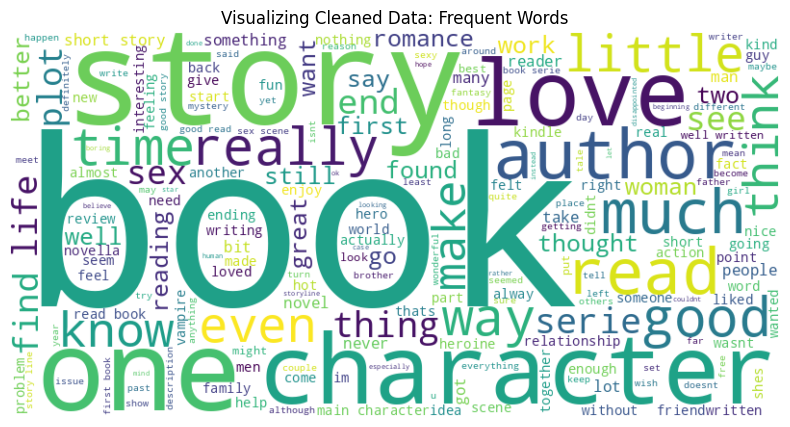

In [32]:
# Function to clean text: remove noise, lowercase, and lemmatize
def clean_text(text):
    text = text.lower()
    # Remove URLs, mentions, hashtags
    text = re.sub(r"http\S+|www\S+|@\w+|#", "", text)
    # Handle basic contractions
    text = re.sub(r"can't", "cannot", text); text = re.sub(r"don't", "do not", text)
    # Remove special characters/numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    text = " ".join([lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words])
    return text

# Apply cleaning and visualize frequent words
df["clean_text"] = df["text"].apply(clean_text)

all_words = ' '.join([text for text in df['clean_text']])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Visualizing Cleaned Data: Frequent Words")
plt.show()

In [33]:
# Convert text to numbers and handle class imbalance
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

VOCAB_SIZE = 15000
MAX_LEN = 250

# Tokenize text
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df["clean_text"])
X = pad_sequences(tokenizer.texts_to_sequences(df["clean_text"]), maxlen=MAX_LEN, padding="post")
y = df["label"].values

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Calculate weights to help model learn rare negative/neutral reviews
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))

# Final label conversion
y_train_cat = to_categorical(y_train, 3)
y_test_cat = to_categorical(y_test, 3)

print("Class Weights calculated:", class_weights)

Class Weights calculated: {0: np.float64(1.0), 1: np.float64(2.0), 2: np.float64(0.6666666666666666)}


In [34]:
# Build the Bi-directional LSTM neural network and train it
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(VOCAB_SIZE, 64, mask_zero=True), # mask_zero handles the padding efficiently
    Bidirectional(LSTM(32)),
    Dense(32, activation="relu"),
    Dropout(0.5), # Regularization to prevent overfitting
    Dense(3, activation="softmax") # Output layer for 3 classes
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Train using class weights and EarlyStopping to find the best epoch
history = model.fit(
    X_train, y_train_cat,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[EarlyStopping(patience=2, restore_best_weights=True)]
)

Epoch 1/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 76s 264ms/step - accuracy: 0.6394 - loss: 0.9109 - val_accuracy: 0.6896 - val_loss: 0.7041
Epoch 2/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 67s 247ms/step - accuracy: 0.7965 - loss: 0.5690 - val_accuracy: 0.6812 - val_loss: 0.7256
Epoch 3/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 68s 250ms/step - accuracy: 0.8877 - loss: 0.3599 - val_accuracy: 0.6792 - val_loss: 0.7840


75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step
Classification Report:
              precision    recall  f1-score   support

    negative       0.85      0.74      0.79       800
     neutral       0.34      0.64      0.45       400
    positive       0.89      0.71      0.79      1200

    accuracy                           0.71      2400
   macro avg       0.69      0.69      0.67      2400
weighted avg       0.78      0.71      0.73      2400



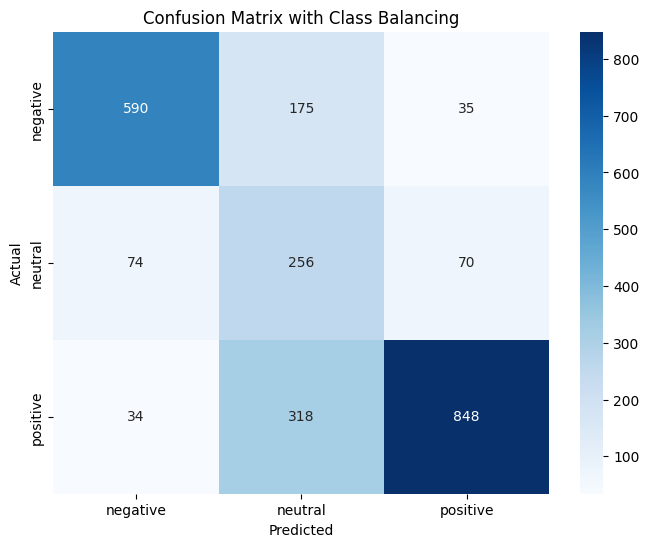

In [35]:
# Evaluate model performance on unseen test data
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix with Class Balancing')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [36]:
# Create an interactive web interface to test the model
import gradio as gr

def predict_sentiment(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding="post")
    pred_probs = model.predict(padded)
    predicted_class = np.argmax(pred_probs)
    return target_names[predicted_class]

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=2, placeholder="Type a review here..."),
    outputs="text",
    title="Book Review Sentiment Analyzer",
    description="Enter a review to see if the AI thinks it is Positive, Neutral, or Negative."
)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0365b1442f5011da2e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
